<a href="https://colab.research.google.com/github/SamManuJacob/6thSem-ML-Lab/blob/main/1BM23CS291_Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== IRIS DATASET ==========
Linear Kernel Accuracy: 1.0
Linear Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Kernel Accuracy: 1.0
RBF Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

========== DRUG DATASET ==========
Accuracy: 0.625
Confusion Matrix:
 [[ 0  0  0  6  0]
 [ 0  0  0  3  0]
 [ 0  0  0  4  1]
 [ 0  0  0 10  1]
 [ 0  0  0  0 15]]

========== LETTER DATASET ==========
Accuracy: 0.9305
Confusion Matrix:
 [[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0  

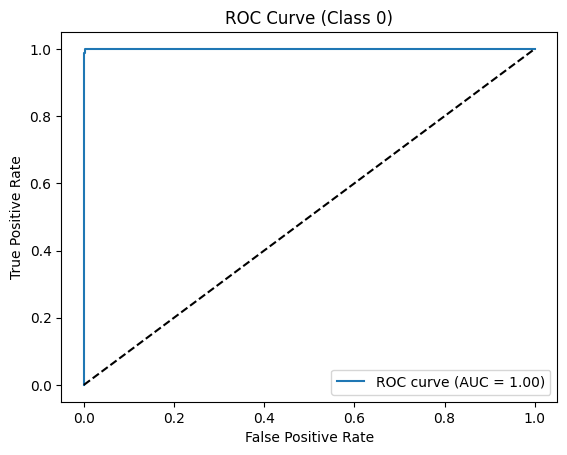


AUC Score (Class 0): 0.999937260260126


In [4]:
# ===================== IMPORTS =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize
import matplotlib.pyplot as plt


# ===================== IRIS DATASET =====================
iris = pd.read_csv('iris (1).csv')

X = iris.drop('species', axis=1)
y = iris['species']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Linear Kernel
model_linear = SVC(kernel='linear', probability=True)
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)

# RBF Kernel
model_rbf = SVC(kernel='rbf', probability=True)
model_rbf.fit(X_train, y_train)
y_pred_rbf = model_rbf.predict(X_test)

print("========== IRIS DATASET ==========")
print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Linear Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("RBF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))


# ===================== DRUG DATASET =====================
drug = pd.read_csv('drug.csv')

le = LabelEncoder()
for col in drug.columns:
    if drug[col].dtype == object:
        drug[col] = le.fit_transform(drug[col])

X = drug.drop('Drug', axis=1)
y = drug['Drug']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n========== DRUG DATASET ==========")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# ===================== LETTER DATASET =====================
letter = pd.read_csv('letter-recognition.csv')

X = letter.drop('letter', axis=1)
y = letter['letter']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n========== LETTER DATASET ==========")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# ===================== ROC & AUC =====================
# Binarize output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for first class
plt.figure()
plt.plot(fpr[0], tpr[0], label="ROC curve (AUC = %0.2f)" % roc_auc[0])
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class 0)")
plt.legend(loc="lower right")
plt.show()

print("\nAUC Score (Class 0):", roc_auc[0])